ลำดับขั้นตอนที่ทำ

---

1.เตรียมข้อมูล + แบ่ง Train/Test :	1–6

2.Train Model :	7

3.Test + วัด Metric :	7

4.นำโมเดลไป Prediction (hub height + MCP ระยะยาว) :	8–9

5.Weibull → AEP → P50/P90 :	10–12


---



# A ขั้นตอนที่ 1

Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma as gamma_fn

สร้างข้อมูลจำลอง สำหรับทดสอบ

In [3]:
rng = np.random.default_rng(42)

# --- สัญญาณลมภูมิภาครายชั่วโมง 2006-2026 (ต้นทางร่วมของ ERA5 และไซต์) ---
h_idx = pd.date_range("2006-01-01", "2026-10-07 23:00", freq="1h")
nh = len(h_idx)
w = rng.normal(0, 1, nh)
ar = pd.Series(w).ewm(span=24).mean().to_numpy()
ar = (ar - ar.mean()) / ar.std()                      # ทำให้ลมต่อเนื่อง ไม่กระโดด
seas = 1 + 0.22*np.sin(2*np.pi*(h_idx.dayofyear-30)/365)      # รอบฤดู
yr_off = pd.Series(rng.normal(1, 0.05, h_idx.year.nunique()),
                   index=sorted(h_idx.year.unique()))          # ปีแรง/ปีอ่อน
yfac = h_idx.year.map(yr_off).to_numpy()
regional = pd.Series(np.clip((6.2 + 2.3*ar)*seas*yfac, 0.1, 30), index=h_idx)

# --- ERA5 ปลอม = ภูมิภาค + bias (ของจริง ERA5 มักต่ำกว่าไซต์) ---
era5 = pd.DataFrame(
    {"era_ws": np.clip(0.82*regional.to_numpy() + rng.normal(0,0.9,nh) - 0.3, 0.1, 30)},
    index=h_idx)
print("ERA5 corr กับภูมิภาค = %.4f" % np.corrcoef(regional, era5["era_ws"])[0,1])

# --- ข้อมูลเสา ราย 1 นาที ต.ค.2025 - ต.ค.2026 ---
idx = pd.date_range("2025-10-08", "2026-10-07 23:59", freq="1min")
n = len(idx)
base = regional.reindex(idx.union(regional.index)).interpolate("time").reindex(idx).to_numpy()
base = np.clip(base + rng.normal(0, 0.35, n), 0.1, 32)

hours = idx.hour + idx.minute/60
doy = idx.dayofyear
alpha_t = np.clip(0.20 + 0.07*np.cos(2*np.pi*(hours-3)/24) + rng.normal(0,0.015,n), 0.02, 0.45)

def ws_at(h, href=100, noise=0.12):
    return np.clip(base*(h/href)**alpha_t + rng.normal(0,noise,n), 0, None)

df = pd.DataFrame(index=idx); df.index.name = "timestamp"
for col, hh in [("Ch1_Anem_160m_NW_m/s",160), ("Ch2_Anem_160m_SE_m/s",160),
                ("Ch3_Anem_140m_NW_m/s",140), ("Ch4_Anem_120m_NW_m/s",120),
                ("Ch5_Anem_100m_NW_m/s",100), ("Ch6_Anem_80m_NW_m/s",80),
                ("Ch7_Anem_60m_NW_m/s",60)]:
    df[col] = ws_at(hh)

arm = pd.Series(base).rolling(60, min_periods=1).mean().to_numpy()
df["Ch8_Vane_160m_Deg"] = (55 + 8*(arm-arm.mean()) + rng.normal(0,20,n)) % 360
df["Ch1_SD_m/s"]    = np.abs(rng.normal(0.55, 0.15, n))
df["Temperature_C"] = 27 + 4.5*np.sin(2*np.pi*(hours-9)/24) + 3*np.sin(2*np.pi*(doy-100)/365) + rng.normal(0,0.4,n)
df["Pressure_hPa"]  = 1009 + 3*np.sin(2*np.pi*(doy-15)/365) + rng.normal(0,1.5,n)
df["Humidity_pct"]  = np.clip(72 - 16*np.sin(2*np.pi*(hours-9)/24) + rng.normal(0,4,n), 20, 100)

# เจาะรูให้ coverage ~83% (ผสมทั้งขาดกระจาย และ logger ดับเป็นก้อน)
m = rng.random(n) < 0.12
for st, dur in [("2026-01-15", 5*1440), ("2026-04-02", 9*1440)]:
    s = idx.get_indexer([pd.Timestamp(st)], method="nearest")[0]
    m[s:s+dur] = True
df.loc[m, :] = np.nan

print("ข้อมูลดิบ:", df.shape, "coverage = %.2f%%" % (df["Ch5_Anem_100m_NW_m/s"].notna().mean()*100))

ERA5 corr กับภูมิภาค = 0.9232
ข้อมูลดิบ: (525600, 12) coverage = 84.63%


In [14]:
# Option B: Explicitly use display()
display(df)

,WS160_NW,WS160_SE,WS140,WS120,WS100,WS80,WS60,WD,SD160,Temp,Pres,RH
timestamp,,,,,,,,,,,,
2025-10-08 00:00:00,7.835169,8.076337,7.722356,7.433968,6.866927,6.679091,6.431070,73.595238,0.654167,23.799857,1006.076870,87.684797
2025-10-08 00:01:00,8.642204,8.559187,8.243897,7.834030,7.585390,7.124795,6.784703,90.082550,0.617658,23.847345,1007.092648,86.241189
2025-10-08 00:02:00,8.569671,8.230638,8.139006,7.794718,7.603401,7.152154,6.527805,67.691352,0.362478,23.558186,1004.093489,86.548147
2025-10-08 00:03:00,7.231061,7.309747,6.721094,6.709583,6.500666,6.246132,5.841783,54.421064,0.666603,23.765892,1005.166997,84.829342
2025-10-08 00:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-07 23:55:00,6.872598,6.793413,6.495491,6.229497,5.990213,5.666218,5.237946,58.812062,0.475614,24.489640,1003.857940,82.018501
2026-10-07 23:56:00,6.188531,6.013867,5.958481,5.819671,5.613148,4.947885,4.701360,50.661143,0.490092,24.993852,1006.447999,85.508806
2026-10-07 23:57:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


ตรวจสอบโครงสร้าง และค่าข้อมูลขาดหาย

In [4]:
s = df["Ch5_Anem_100m_NW_m/s"]
miss = s.isna()
runs = miss.groupby((~miss).cumsum()[miss]).sum()

print("ช่องว่างยาวสุด: %d นาที (%.1f ชม.)" % (runs.max(), runs.max()/60))
print("จำนวนช่วงที่ขาด: ", len(runs))
print("ช่วงที่ขาดนานเกิน 1 ชม.: ", (runs > 60).sum())
print("\n Coverage รายเดือน (%): ")
print((s.notna().resample("MS").mean()*100).round(1).to_string())

ช่องว่างยาวสุด: 12960 นาที (216.0 ชม.)
จำนวนช่วงที่ขาด:  53362
ช่วงที่ขาดนานเกิน 1 ชม.:  2

 Coverage รายเดือน (%): 
timestamp
2025-10-01    87.9
2025-11-01    87.8
2025-12-01    88.0
2026-01-01    74.0
2026-02-01    88.2
2026-03-01    88.0
2026-04-01    61.7
2026-05-01    87.9
2026-06-01    87.9
2026-07-01    88.2
2026-08-01    88.1
2026-09-01    87.9
2026-10-01    87.9
Freq: MS


เปลี่ยนชื่อคอลัมน์ และตรวจข้อมูลรายนาที

In [5]:
RENAME = {
    "Ch1_Anem_160m_NW_m/s":"WS160_NW", "Ch2_Anem_160m_SE_m/s":"WS160_SE",
    "Ch3_Anem_140m_NW_m/s":"WS140",    "Ch4_Anem_120m_NW_m/s":"WS120",
    "Ch5_Anem_100m_NW_m/s":"WS100",    "Ch6_Anem_80m_NW_m/s":"WS80",
    "Ch7_Anem_60m_NW_m/s":"WS60",      "Ch8_Vane_160m_Deg":"WD",
    "Ch1_SD_m/s":"SD160", "Temperature_C":"Temp",
    "Pressure_hPa":"Pres", "Humidity_pct":"RH",
}
df = df.rename(columns=RENAME)
WS_COLS = ["WS160_NW","WS160_SE","WS140","WS120","WS100","WS80","WS60"]

def clean_ws(s, vmin=0, vmax=40, stuck_n=60):
  """stuck_n = 60 เพราะข้อมูลราย 1 นาที -> ค่าค้าง 60 จุด = 1 ชม."""
  s = s.where((s >= vmin) & (s <= vmax))
  same = s.diff().abs() < 1e-6
  run = same.groupby((~same).cumsum()).cumcount() + 1
  return s.mask(run >= stuck_n)

for c in WS_COLS:
  df[c] = clean_ws(df[c])

print("Coverage ราย 1 นาที หลัง QC (%):")
print((df[WS_COLS].notna().mean()*100).round(2).to_string())

# ตรวจสอบความสอดคล้องเซนเซอร์คู่ที่ 160 ม.
d = df["WS160_NW"] - df["WS160_SE"]
print("\nNW-SW: mean = %.3f |mean abs| = %.3f corr = %.4f"
      % (d.mean(), d.abs().mean(), df["WS160_NW"].corr(df["WS160_SE"])))

Coverage ราย 1 นาที หลัง QC (%):
WS160_NW    84.63
WS160_SE    84.63
WS140       84.63
WS120       84.63
WS100       84.63
WS80        84.63
WS60        84.63

NW-SW: mean = -0.000 |mean abs| = 0.135 corr = 0.9986


Resample 1 นาที ให้เป็น 10 นาทีและคำนวณ TI

In [6]:
MIN_SAMPLES = 7

out = pd.DataFrame(index=df.resample("10min").mean().index)

for c in WS_COLS:
  mm = df[c].resample("10min").mean()
  kk = df[c].resample("10min").count()
  out[c] = mm.where(kk >= MIN_SAMPLES)

# ทิศทางลม เฉลี่ยแบบเวกเตอร์ (ห้ามเฉลี่ยองศาตรงๆ)
rad = np.deg2rad(df["WD"])
u = np.sin(rad).resample("10min").mean()
v = np.cos(rad).resample("10min").mean()
out["WD"] = np.degrees(np.arctan2(u, v)) % 360

for c in ["Temp","Pres","RH"]:
  out[c] = df[c].resample("10min").mean()

# TI: กฏความแปรปรวนรวม σ² (10 นาที) = mean(σ² ในนาที) + var(ค่าเฉลี่ยรายนาที)
var_w = (df["SD160"]**2).resample("10min").mean()
var_b = df["WS160_NW"].resample("10min").var()
out["TI"] = np.sqrt(var_w.fillna(0) + var_b.fillna(0)) / out["WS160_NW"]

print("หลัง resample:", out.shape)
print("Coverage ราย 10 นาที (%):")
print((out[WS_COLS].notna().mean()*100).round(2).to_string())

bin15 = (out["WS160_NW"] >= 14) & (out["WS160_NW"] < 16)
print("\nTI ที่ช่วง 15 m/s (ใช้เลือกคลาสกังหัน ตาม IEC): %.4f" % out.loc[bin15,"TI"].mean())

หลัง resample: (52560, 12)
Coverage ราย 10 นาที (%):
WS160_NW    93.9
WS160_SE    93.9
WS140       93.9
WS120       93.9
WS100       93.9
WS80        93.9
WS60        93.9

TI ที่ช่วง 15 m/s (ใช้เลือกคลาสกังหัน ตาม IEC): 0.0479


แก้เงาเสา + สร้าง Feature + หา α

In [7]:
# --- เลือกเซนเซอร์ 160 ม. ตามทิศลม (แขนชี้เข้าหาลม = ไม่โดนเงาเสา) ---
BOOM = {"WS160_NW": 315.0, "WS160_SE": 135.0}   # ⚠️ ต้องยืนยันกับทีมเสาวัด
ang_diff = lambda a, b: np.abs((a - b + 180) % 360 - 180)

d_nw = ang_diff(out["WD"], BOOM["WS160_NW"])
d_se = ang_diff(out["WD"], BOOM["WS160_SE"])
out["WS160"] = pd.Series(np.where(d_nw <= d_se, out["WS160_NW"], out["WS160_SE"]),
                         index=out.index)
out["WS160"] = out["WS160"].fillna(out["WS160_NW"].fillna(out["WS160_SE"]))

# --- Feature ---
r2 = np.deg2rad(out["WD"])
out["wd_sin"], out["wd_cos"] = np.sin(r2), np.cos(r2)
hh = out.index.hour + out.index.minute/60
out["hr_sin"], out["hr_cos"] = np.sin(2*np.pi*hh/24), np.cos(2*np.pi*hh/24)
dd = out.index.dayofyear
out["doy_sin"], out["doy_cos"] = np.sin(2*np.pi*dd/365), np.cos(2*np.pi*dd/365)
out["dws"] = out["WS100"] - out["WS60"]

FEATURES = ["WS60","WS80","WS100","dws","wd_sin","wd_cos",
            "Temp","Pres","RH","hr_sin","hr_cos","doy_sin","doy_cos"]

# --- α จริงจากข้อมูล (แทนที่ 0.185 ที่ไม่มีที่มา) ---
ok = (out["WS100"] > 3) & (out["WS160"] > 3)
out["alpha_obs"] = np.nan
out.loc[ok,"alpha_obs"] = np.log(out.loc[ok,"WS160"]/out.loc[ok,"WS100"]) / np.log(160/100)
alpha_site = out["alpha_obs"].median()
print("α ของไซต์ (median) = %.4f" % alpha_site)

# --- แบ่ง train/test ตามเวลา ---
data = out[FEATURES + ["WS160","alpha_obs"]].dropna()
split = data.index[int(len(data)*0.7)]
train, test = data.loc[:split], data.loc[split:]
print("ใช้ได้ %d แถว | สอน %d | สอบ %d" % (len(data), len(train), len(test)))
print("สอน:", train.index.min().date(), "→", train.index.max().date())
print("สอบ:", test.index.min().date(),  "→", test.index.max().date())

α ของไซต์ (median) = 0.2010
ใช้ได้ 46446 แถว | สอน 32513 | สอบ 13934
สอน: 2025-10-08 → 2026-06-25
สอบ: 2026-06-25 → 2026-10-07


# B ขั้นตอนที่ 2-3
เทรนโมเดล และวัดผล

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def report(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    m = y_true > 3
    mape = np.mean(np.abs((y_true[m]-y_pred[m])/y_true[m]))*100
    print(f"{name:24s} MAE={mae:.3f} RMSE={rmse:.3f} MAPE={mape:.2f}% R²={r2:.4f}")

X_train, y_train = train[FEATURES], train["WS160"]
X_test,  y_test  = test[FEATURES],  test["WS160"]

# --- Baseline ก่อนเสมอ ---
report(y_test, X_test["WS100"]*(160/100)**alpha_site, "Power Law (baseline)")

lr = LinearRegression().fit(X_train, y_train)
report(y_test, lr.predict(X_test), "Linear Regression")

# --- ML ---
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features="sqrt",
                           random_state=42, n_jobs=-1).fit(X_train, y_train)
report(y_test, rf.predict(X_test), "Random Forest")

# --- RF ที่ทำนาย α (ใช้ตอนต้องขยายเกินเซนเซอร์บนสุด) ---
rf_a = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features="sqrt",
                             random_state=42, n_jobs=-1).fit(X_train, train["alpha_obs"])
report(y_test, X_test["WS100"]*(160/100)**rf_a.predict(X_test), "RF ผ่าน α")

imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nความสำคัญของ feature:\n", imp.round(3).to_string())

Power Law (baseline)     MAE=0.168 RMSE=0.199 MAPE=2.18% R²=0.9931
Linear Regression        MAE=0.064 RMSE=0.081 MAPE=0.94% R²=0.9989
Random Forest            MAE=0.061 RMSE=0.084 MAPE=0.82% R²=0.9988
RF ผ่าน α                MAE=0.049 RMSE=0.062 MAPE=0.69% R²=0.9993

ความสำคัญของ feature:
 WS100      0.282
WS80       0.223
WS60       0.211
wd_cos     0.127
wd_sin     0.067
dws        0.059
doy_sin    0.013
Pres       0.010
doy_cos    0.003
RH         0.003
Temp       0.002
hr_sin     0.001
hr_cos     0.001


# C ขั้นตอนที่ 4 นำโมเดลไป Prediction

ทายความเร็วลมที่ hub height

In [9]:
HUB = 150          # 🔧 สมมติ — ต้องเปลี่ยนเป็น hub height จริงของกังหันที่เลือก

full = out[FEATURES].dropna()
a_pred = rf_a.predict(full)
ws_hub = pd.Series(full["WS100"].to_numpy()*(HUB/100)**a_pred, index=full.index, name="ws_hub")

print("ความเร็วลมที่ hub %d ม.: mean=%.3f m/s (n=%d)" % (HUB, ws_hub.mean(), len(ws_hub)))
print("เทียบ Power Law ล้วน:  mean=%.3f m/s"
      % (full["WS100"]*(HUB/100)**alpha_site).mean())

ความเร็วลมที่ hub 150 ม.: mean=7.870 m/s (n=49356)
เทียบ Power Law ล้วน:  mean=7.872 m/s


Enhanced MCP: ขยาย 1 ปี -> 20 ปี

In [10]:
# จับคู่ ERA5 (รายชั่วโมง) กับไซต์ ในช่วงที่ทับซ้อนกัน
site_h = ws_hub.resample("1h").mean().dropna()
ov = era5.join(site_h.rename("site"), how="inner").dropna().copy()

for d_, name in [(ov, "ov")]:
    d_["m_sin"] = np.sin(2*np.pi*d_.index.dayofyear/365)
    d_["m_cos"] = np.cos(2*np.pi*d_.index.dayofyear/365)
    d_["h_sin"] = np.sin(2*np.pi*d_.index.hour/24)
    d_["h_cos"] = np.cos(2*np.pi*d_.index.hour/24)

MF = ["era_ws","m_sin","m_cos","h_sin","h_cos"]
sp2 = ov.index[int(len(ov)*0.7)]
mcp = RandomForestRegressor(n_estimators=300, min_samples_leaf=10,
                            random_state=42, n_jobs=-1)
mcp.fit(ov.loc[:sp2, MF], ov.loc[:sp2, "site"])

print("ช่วงทับซ้อน %d ชั่วโมง" % len(ov))
report(ov.loc[sp2:,"site"], mcp.predict(ov.loc[sp2:,MF]), "MCP (ERA5→ไซต์)")

# เอาโมเดลไปทายย้อนหลัง 20 ปี
lt = era5.copy()
lt["m_sin"] = np.sin(2*np.pi*lt.index.dayofyear/365)
lt["m_cos"] = np.cos(2*np.pi*lt.index.dayofyear/365)
lt["h_sin"] = np.sin(2*np.pi*lt.index.hour/24)
lt["h_cos"] = np.cos(2*np.pi*lt.index.hour/24)
lt["ws_lt"] = mcp.predict(lt[MF])

yr = lt["ws_lt"].resample("YS").mean()
iav = yr.std()/yr.mean()
print("\nลมระยะยาว %d ชม. | mean=%.3f m/s" % (len(lt), lt["ws_lt"].mean()))
print("ความผันผวนปีต่อปี (IAV) = %.2f%%" % (iav*100))
print("ปีที่วัดจริง mean=%.3f → ต่างจากค่าระยะยาว %.2f%%"
      % (ws_hub.mean(), (ws_hub.mean()/lt["ws_lt"].mean()-1)*100))

ช่วงทับซ้อน 8424 ชั่วโมง
MCP (ERA5→ไซต์)          MAE=0.983 RMSE=1.237 MAPE=14.15% R²=0.7662

ลมระยะยาว 182040 ชม. | mean=7.099 m/s
ความผันผวนปีต่อปี (IAV) = 6.14%
ปีที่วัดจริง mean=7.870 → ต่างจากค่าระยะยาว 10.87%


# D ขั้นตอนที่ 5 : Weibull -> AEP -> P50/P90

ฟิต Weibull

Weibull:  k (รูปร่าง) = 2.937   A (สเกล) = 7.953 m/s
mean จากสูตร = 7.095 | mean จากข้อมูล = 7.099


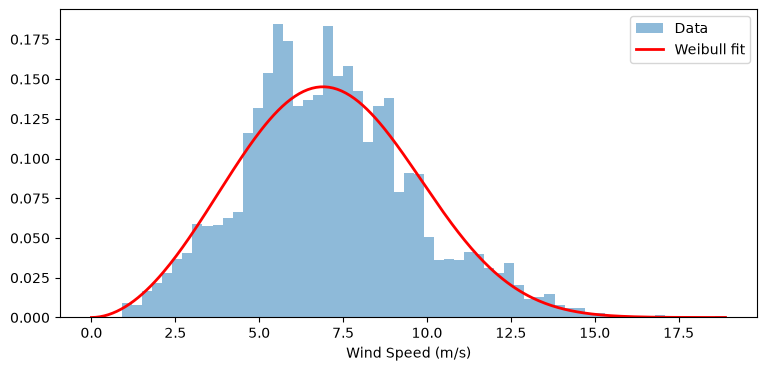

In [11]:
v = lt["ws_lt"].dropna().to_numpy()
v = v[v > 0]

k, loc, A = stats.weibull_min.fit(v, floc=0)     # floc=0 บังคับให้เริ่มที่ 0
print("Weibull:  k (รูปร่าง) = %.3f   A (สเกล) = %.3f m/s" % (k, A))
print("mean จากสูตร = %.3f | mean จากข้อมูล = %.3f" % (A*gamma_fn(1+1/k), v.mean()))

plt.figure(figsize=(9,4))
plt.hist(v, bins=60, density=True, alpha=.5, label="Data")
xs = np.linspace(0, v.max(), 300)
plt.plot(xs, stats.weibull_min.pdf(xs, k, 0, A), 'r-', lw=2, label="Weibull fit")
plt.xlabel("Wind Speed (m/s)"); plt.legend(); plt.show()

Air Density + Power Curve -> AEP

In [12]:
# --- Air Density: ρ = P/(R·T) ---
T = out["Temp"].mean() + 273.15
P = out["Pres"].mean() * 100          # hPa → Pa
rho = P / (287.05 * T)
print("ρ = %.4f kg/m³  (T=%.1f°C, P=%.1f hPa)" % (rho, T-273.15, P/100))

# --- Power Curve สมมติ: กังหัน 4.5 MW ---
# 🔧 ต้องเปลี่ยนเป็น power curve จริงจากผู้ผลิตกังหันที่เลือก
def power_curve(ws, rated=4500., ci=3., vr=12., co=25.):
    p = np.zeros_like(ws, dtype=float)
    ramp = (ws >= ci) & (ws < vr)
    p[ramp] = rated * ((ws[ramp]**3 - ci**3) / (vr**3 - ci**3))
    p[(ws >= vr) & (ws <= co)] = rated
    return p

# --- AEP = Σ [P(v) × f(v) × 8760] ---
bins = np.arange(0, 30.5, 0.5)
ctr  = (bins[:-1] + bins[1:]) / 2
f = np.diff(stats.weibull_min.cdf(bins, k, loc=0, scale=A))
f = f / f.sum()

v_corr = ctr * (rho/1.225)**(1/3)     # ปรับความเร็วตาม air density (IEC, pitch-regulated)
p_kw = power_curve(v_corr)
aep_gross = np.sum(p_kw * f * 8760) / 1e6

# --- หัก loss ---
WAKE, AVAIL, ELEC, OTHER = 0.05, 0.03, 0.02, 0.02    # 🔧 ค่าสมมติ
aep_net = aep_gross * (1-WAKE)*(1-AVAIL)*(1-ELEC)*(1-OTHER)

print("AEP gross = %.3f GWh/ปี" % aep_gross)
print("AEP net   = %.3f GWh/ปี  (หัก wake/ความพร้อม/ไฟฟ้า/อื่นๆ)" % aep_net)

ρ = 1.1708 kg/m³  (T=27.0°C, P=1008.9 hPa)
AEP gross = 10.290 GWh/ปี
AEP net   = 9.107 GWh/ปี  (หัก wake/ความพร้อม/ไฟฟ้า/อื่นๆ)


P50 / P75 / P90 + Capacity Factor

In [13]:
# 🔧 ค่า uncertainty ทั้งหมดเป็นค่าสมมติ ต้องเปลี่ยนเป็นค่าจริงของโครงการ
unc = {
    "การวัด (measurement)":      0.030,
    "ขยายความสูง (vertical)":    0.040,
    "MCP / ระยะยาว":             0.035,
    "Power curve":               0.050,
    "Wake / ความพร้อมใช้งาน":     0.030,
    "ความผันผวนปีต่อปี (IAV)":    float(iav),   # ← ได้จากขั้น 4
}
sigma = np.sqrt(sum(x**2 for x in unc.values()))   # รวมแบบ root-sum-square

print("องค์ประกอบความไม่แน่นอน:")
for kk_, vv in unc.items():
    print("  %-28s %.2f%%" % (kk_, vv*100))
print("  %-28s %.2f%%" % ("รวม (σ_total)", sigma*100))

P50 = aep_net
P75 = aep_net * (1 - stats.norm.ppf(0.75)*sigma)
P90 = aep_net * (1 - stats.norm.ppf(0.90)*sigma)

print("\n  P50 = %.3f GWh/ปี   (ค่ากลาง)" % P50)
print("  P75 = %.3f GWh/ปี" % P75)
print("  P90 = %.3f GWh/ปี   ← ธนาคารใช้ตัวนี้เป็นเกณฑ์ปล่อยกู้" % P90)
print("\n  Capacity Factor = %.2f%%" % (aep_net*1e6/(4500*8760)*100))

องค์ประกอบความไม่แน่นอน:
  การวัด (measurement)         3.00%
  ขยายความสูง (vertical)       4.00%
  MCP / ระยะยาว                3.50%
  Power curve                  5.00%
  Wake / ความพร้อมใช้งาน       3.00%
  ความผันผวนปีต่อปี (IAV)      6.14%
  รวม (σ_total)                10.44%

  P50 = 9.107 GWh/ปี   (ค่ากลาง)
  P75 = 8.466 GWh/ปี
  P90 = 7.889 GWh/ปี   ← ธนาคารใช้ตัวนี้เป็นเกณฑ์ปล่อยกู้

  Capacity Factor = 23.10%
